# Capacity Management: What to do when your best model runs out

**Turn your evaluations into a capacity planning tool, pick your cost performance, and stop leaving throughput on the table.**

## Overview

Most model evaluation asks *"which model is best?"* and ships the winner. That works right up until
your workload outgrows what a single model will serve you, your model is deprecated, or your manager asks why it costs quite so much.

For some of the largest workloads in the world, the binding constraint stops being quality and becomes **quota**. If you
need 1,000 requests per minute and your best model gives you 400, no amount of prompt engineering on
that one model fixes the problem. You need several models, and you need to know which ones are good
enough to trust with production traffic. Moreover, you don't just test. You **optimize** your workload for every model you're testing on. 

This reframes model selection from a ranking problem into a **portfolio** problem, and it gives
evaluation a new job: deciding who is allowed in the portfolio. This module builds toward a single
metric to capture this idea:

> **Quality-weighted capacity** = the sum of the quota of every model that passes your quality bar.

When you do an evaluation and ask *"which model is best?"* the answer is always exactly one model.  When you instead ask *"which models will work* you get a list of models.  This reframing has many benefits:

  - Access to the full capacity of all the models in your portfolio
  - Changing models becomes a breeze, whether that's because you want to try out the new latest and greatest or some of your favorites get deprecated.
  - You control your cost in real time.  You decide how how to balance latency, quality, and cost  and to make changes in real time by editing your portfolio of approved models.
  - Insight into the most costly portions of a workload, allowing you to consider decomposing them into smaller, cheaper steps 


The catalyst that makes all of this possible is automatic prompt optimization. It's not enough to test against all the different models. You need to optimize your workload for each model, creating a version of your workload that works the best for each model. In this notebook, we walk through this entire process, with the intent of making it easy to adapt to your own workloads. By the end of the notebook, we will have taken an example workload from 400 RPM on a single model to 900 RPM across a routed portfolio, without asking for more quota.

## What You'll Learn

1. **Token bucket rate limiting** — how Bedrock throttling actually works, and why "6 per minute"
   does not mean "wait for the top of the minute"
2. **Measuring a workload across a model portfolio** — accuracy, cost per 1,000 requests, and
   latency measured per model rather than assumed from a leaderboard
3. **Advanced Prompt Optimization (AdvPO)** — optimizing one prompt for five models in a single job,
   with a custom Lambda evaluator, and reading the results back
4. **Capacity-aware routing** — a priority-ordered router with queueing that spends quota from
   whichever model has it, using the prompt tuned for that model
5. **Admission with a quality bar and a cost ceiling** — deciding which models are even allowed
   into the portfolio, and what quota that decision is worth in aggregate

Every number in this notebook is measured against real Amazon Bedrock, not estimated.

## The Sample Workload

**BANKING77 intent classification.** 13,083 real online-banking customer service messages, each
labelled with one of 77 fine-grained intents. This is used for support triage and is an example with very high volume, short inputs, short outputs, objective ground truth, and 77 confusable classes that separate strong models from weak ones.

A sampled subset is included under `data/`, so no download is needed.  If you'd like to use the full dataset, you can find it here:

> BANKING77 is from Casanueva et al., *Efficient Intent Detection with Dual Sentence Encoders*,
> published at [PolyAI-LDN/task-specific-datasets](https://github.com/PolyAI-LDN/task-specific-datasets)
> and licensed CC-BY-4.0.

## Models Used

Five text models across three providers. Spreading a portfolio across providers matters: models from
one provider tend to share correlated outages.

| Model | ID | $/1M in | $/1M out |
|---|---|---|---|
| Amazon Nova 2 Lite | `us.amazon.nova-2-lite-v1:0` | 0.33 | 2.75 |
| Anthropic Claude Haiku 4.5 | `us.anthropic.claude-haiku-4-5-20251001-v1:0` | 1.00 | 5.00 |
| Anthropic Claude Sonnet 5 | `us.anthropic.claude-sonnet-5` | 3.00 | 15.00 |
| OpenAI gpt-oss-120b | `openai.gpt-oss-120b-1:0` | 0.15 | 0.60 |
| OpenAI GPT-5.6 Luna | `us.openai.gpt-5.6-luna` | 0.20 | 1.20 |

Model IDs, pricing, and quota tables live in [`model_config.py`](model_config.py) — edit that one
file to swap models across the whole notebook.

## Prerequisites

- AWS account with Amazon Bedrock access in **us-east-1**
- Model access enabled for all five models above (Bedrock console, Model access)
- Python 3.10+
- Completion of the [Foundational Evaluations](../../Foundational%20Evaluations/) modules

**Estimated time**: 45-60 minutes, of which roughly 15 minutes is Bedrock calls and a few minutes is
*deliberate* waiting on simulated quota.

**Estimated cost**: under $3 in on-demand inference.

Let's get started!

---
## 1. Setup

The module ships three helper files so the notebook stays readable. Each one is also the file
you would touch to point this whole workflow at your own workload, so it is worth knowing what
lives where and why.

**[`capacity.py`](capacity.py) — the part that is *not* specific to this workload.** We don't want to actually max out your quota in order to test things, so we enforce an artificial limit on all models for this example. (the actual limits are set in the model_config.py file.) This script is
where `TokenBucket`, `QuotaSimulator`, and `CapacityRouter` live: the continuous-refill rate
limiter, the per-model quota tracking built on top of it, and the priority-ordered router with
queueing that everything else in the notebook is built around. It also has `run_workload` for
pushing a batch of items through the router concurrently, and `simulate_routing` for the free,
instant what-if simulations we use later to project to production volume. Nothing in this file
knows about BANKING77, intents, or prompts — it only knows about models, quotas, and requests. If
you are adapting this module to a different workload, this file should not need to change at all.

**[`model_config.py`](model_config.py) — the knobs you are most likely to turn.** Model IDs,
per-model pricing, and the three quota tables (`DEMO_QUOTAS` for the throttling demos,
`EVAL_QUOTAS` for the quality sweeps, `PRODUCTION_QUOTAS_EXAMPLE` for the projection section) all
live here, along with the `ADVPO_MODEL_IDS` mapping that papers over the fact that Advanced Prompt
Optimization and the Converse API do not always agree on what to call a model. To swap in a
different set of models, add pricing for a new one, or change how aggressive the simulated
throttling is, this is the file to edit — then restart the kernel and re-run from the top.

**[`banking77.py`](banking77.py) — the part that *is* specific to this workload.** The dataset
loaders, the baseline and AdvPO prompt templates, `normalize_label` (the grader, including its two
fallback strategies), and `summarize` (which turns a batch of results into the accuracy, cost, and
latency metrics used throughout the notebook) all live here. This is the file you would replace
wholesale to point the module at a different task: swap the data loaders for your own dataset,
write a prompt template for your task, and adjust the grader to match how your task's output should
be checked. `capacity.py` and `model_config.py` do not need to know anything changed.

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [43]:
import json
import time

import pandas as pd

#Import our three helper scripts and their functions as described above.
import banking77 as b77
import model_config as mc
from capacity import (CapacityRouter, QuotaSimulator, SimulatedThrottlingException,
                      TokenBucket, VirtualClock, run_workload, simulate_routing)

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

EVAL_SET = b77.load_eval_set()

print(f"region            : {mc.REGION}")
print(f"models            : {len(mc.CANDIDATE_MODELS)}")
print(f"evaluation items  : {len(EVAL_SET)}  ({len({i['label'] for i in EVAL_SET})} distinct intents)")
print(f"intent labels     : {len(b77.LABELS)}")
print()
for m in mc.CANDIDATE_MODELS:
    p = mc.MODEL_PRICING[m]
    print(f"  {mc.friendly(m):<20} {mc.MODEL_PROVIDERS[m]:<22} "
          f"${p['input']:>5.2f} in / ${p['output']:>6.2f} out per 1M tokens")

# --- charting -------------------------------------------------------------
# The Okabe-Ito colourblind-safe palette, plus a fixed colour per model so the
# same model reads the same way in every chart in this notebook.
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

BLUE, ORANGE, GREEN, RED, SKY, PURPLE, GREY = (
    "#0072B2", "#E69F00", "#009E73", "#D55E00", "#56B4E9", "#CC79A7", "#999999")

MODEL_COLOURS = {
    mc.GPT_56_LUNA: BLUE,
    mc.GPT_OSS_120B: SKY,
    mc.CLAUDE_HAIKU_45: GREEN,
    mc.CLAUDE_SONNET_5: PURPLE,
    mc.NOVA_2_LITE: ORANGE,
}

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "legend.frameon": False,
                     "axes.titleweight": "bold"})

region            : us-east-1
models            : 5
evaluation items  : 154  (77 distinct intents)
intent labels     : 77

  Nova 2 Lite          Amazon                 $ 0.33 in / $  2.75 out per 1M tokens
  Claude Haiku 4.5     Anthropic              $ 1.00 in / $  5.00 out per 1M tokens
  Claude Sonnet 5      Anthropic              $ 3.00 in / $ 15.00 out per 1M tokens
  gpt-oss-120b         OpenAI (open weight)   $ 0.15 in / $  0.60 out per 1M tokens
  GPT-5.6 Luna         OpenAI                 $ 0.20 in / $  1.20 out per 1M tokens


### Sample Workload
A quick look at the testing data.  The goal here is to classify intent from the text. Note how close some of these intents are to each other, which is what makes this a challenging task that smaller models might struggle with.

In [3]:

pd.DataFrame(EVAL_SET[:8])

,text,label
0,Somehow I am missing my card. What should I do?,lost_or_stolen_card
1,"May I use my account now, even though the identity verif...",why_verify_identity
2,I want my account deleted!,terminate_account
3,My transfer did not seem to work.,failed_transfer
4,Can I use this card at an ATM?,atm_support
5,Double check your funds may be declined,declined_transfer
6,Can you explain why there is a payment showing twice?,transaction_charged_twice
7,I have a direct debit charge that I do not recognize,direct_debit_payment_not_recognised


### The baseline prompt

This is a deliberately ordinary first attempt: describe the job, list the 77 intents, ask for the
answer. It is the prompt someone writes before they have run an evaluation, and it is the thing we
are going to try to beat.  It's defined in full in our dataset file banking77.py, so we'll load a snippet here to take a look.

The prompt template uses `{{customerMessage}}`, which is where the eval dataset input will go.  This is also Advanced Prompt
Optimization's placeholder syntax, so we can use it for an optimization job in section 6.

In [52]:
print(b77.BASELINE_TEMPLATE[:200])
print("   ... 77 intent labels ...")
print(b77.BASELINE_TEMPLATE[-200:])

You are a customer service assistant for a digital bank.
Classify the customer's message into one of the following intents:

card_arrival
card_linking
exchange_rate
card_payment_wrong_exchange_rate
ex
   ... 77 intent labels ...
op_up_by_card_charge
activate_my_card
cash_withdrawal_charge
card_about_to_expire
apple_pay_or_google_pay
verify_my_identity
country_support

Customer message: {{customerMessage}}

What is the intent?


In [53]:
# We can also look at the prompt with the first eval dataset slotted in.
example = b77.render_prompt(b77.BASELINE_TEMPLATE, EVAL_SET[0]["text"])
print(example[:200])
print("   ... 77 intent labels ...")
print(example[-200:])

You are a customer service assistant for a digital bank.
Classify the customer's message into one of the following intents:

card_arrival
card_linking
exchange_rate
card_payment_wrong_exchange_rate
ex
   ... 77 intent labels ...
_my_card
cash_withdrawal_charge
card_about_to_expire
apple_pay_or_google_pay
verify_my_identity
country_support

Customer message: Somehow I am missing my card.  What should I do?

What is the intent?


---

## 2. How does Bedrock throttling actually work?

Before we can route around a quota, we need an accurate mental model of the quota. 

Bedrock enforces limits with a **token bucket**, which slowly fills over time.

Consider a model which is limited at "6 requests per minute"

| | Fixed window | Token bucket |
|---|---|---|
| "6 per minute" means | 6 requests, then wait for the next minute boundary | a bucket holding 6, refilling continuously at 6/60 = 0.1 per second |
| Spend all 6 at once | blocked until the window resets | one more request becomes available every 10 seconds |
| Burst behaviour | resets in a cliff | smooth, and you can burst up to the bucket size after idling |

So if you are limited to 6 requests per minute and you spend all 6 immediately, you are not
locked out for a minute. You earn one request back every 10 seconds. A client that waits
those 10 seconds gets served; a client that gives up on the first 429 does not.

### Three notes on realism

**We simulate the quota.** Real Bedrock limits are high enough that reaching them in a
workshop would take thousands of requests and real money. We impose much smaller artificial
limits so throttling is observable in seconds. The mechanics are identical, the numbers are
just smaller — tune `DEMO_QUOTAS` in `model_config.py` to trade runtime against realism.

**A local limiter is not as artificial as it looks.** In production it is common to put a
per-workload or per-tenant limiter *in front of* Bedrock so one workload cannot drain the
account's quota. In that architecture a local limiter that knows its own budget is exactly
what you run. Our simulator is that limiter.

**We model requests per minute only.** Bedrock also enforces tokens per minute, and RPM is
not enforced for every model — several models are governed by token quotas alone. Whichever
limit binds first, the routing lesson is the same, so we keep one dimension for clarity. In
production, check which limits actually apply to your models and monitor both.

### Here's what a refiling token bucket looks like visually
This assumes we send 12 requests to a model that only supports 6 RPM, and that we are constantly retrying, using quota as soon as it becomes available.

![One model's token bucket draining on a burst and refilling one token every 10 seconds, next to a comparison showing 12 requests completing instantly across five models versus over 60 seconds on one model.](images/fig4-token-bucket-mechanics.png)

---

## 3. What does the naive approach actually cost us?

Let's make the problem concrete with real Bedrock calls. We take a burst of 24 classification
requests and send them all to a single model, with the simulated quota set to 6 RPM. This is the
naive approach, and it is the baseline we beat at the end of the notebook.

First without retry handling, so you can see what a naive client experiences.

In [10]:
BASELINE_MODEL = mc.GPT_56_LUNA        # our strongest candidate, as it turns out
BURST_ITEMS = EVAL_SET[:24]

# The same baseline prompt for every model -- no per-model tuning yet.
def baseline_prompt(item, model_id):
    return b77.render_prompt(b77.BASELINE_TEMPLATE, item["text"])

print(f"quota table (simulated): {mc.DEMO_QUOTAS[BASELINE_MODEL]} RPM per model")
print(f"workload: {len(BURST_ITEMS)} requests -> {mc.friendly(BASELINE_MODEL)} only")

quota table (simulated): 6 RPM per model
workload: 24 requests -> GPT-5.6 Luna only


In [11]:
# mode="fail" raises on the first request that finds no quota, exactly like a
# client that does not handle ThrottlingException.
router = CapacityRouter(quotas=mc.DEMO_QUOTAS, region=mc.REGION, mode="fail")

t0 = time.monotonic()
naive = run_workload(router, BURST_ITEMS, baseline_prompt,
                     model=BASELINE_MODEL, max_workers=12, mode="fail",
                     progress=False)
served = [r for r in naive["records"] if r.ok]
dropped = [r for r in naive["records"] if not r.ok]

print(f"wall clock : {naive['wall_clock_s']:.1f}s")
print(f"served     : {len(served)}/{len(BURST_ITEMS)}")
print(f"dropped    : {len(dropped)} requests lost to throttling")

wall clock : 2.4s
served     : 6/24
dropped    : 18 requests lost to throttling


Fast, and it threw away a third of the workload. In production those are dropped customer
messages.

Now the same burst with queueing enabled.

In [12]:
router.reset()   # refill all buckets so the timing is repeatable
router.mode = "queue"

queued = run_workload(router, BURST_ITEMS, baseline_prompt,
                      model=BASELINE_MODEL, max_workers=12, progress=False)

single_model_summary = b77.summarize(queued["records"], model_id=BASELINE_MODEL)
print(f"wall clock      : {queued['wall_clock_s']:.1f}s")
print(f"served          : {single_model_summary['n_scored']}/{len(BURST_ITEMS)}")
print(f"accuracy        : {single_model_summary['accuracy']:.1%}")
print(f"mean queue wait : {single_model_summary['queue_wait_mean_s']:.1f}s")
print(f"p95 queue wait  : {single_model_summary['queue_wait_p95_s']:.1f}s")
print(f"cost per 1k     : ${single_model_summary['cost_per_1k_usd']:.3f}")

wall clock      : 180.8s
served          : 24/24
accuracy        : 79.2%
mean queue wait : 61.9s
p95 queue wait  : 170.0s
cost per 1k     : $0.123


### Why not just ask for a quota increase?

You can, and should.  Many production workloads are running with an increased quota, not the default.  Nevertheless, quota increases are not guaranteed, they take time, they are per-model and per-region, and the newest and strongest
models are usually the most constrained. Routing is the thing you control today, and it
composes with a quota increase rather than competing with it.

---

## 4. How do the models compare on our workload?

To route across models, we need to know which models are actually acceptable. So let's run the
same 154-item evaluation set against all five, with the same baseline prompt, and measure
three things per model: **accuracy**, **cost per 1,000 classifications**, and **latency**.

Two implementation notes:

**Quotas are relaxed for the evaluation sweeps.** Sections 4 and 7 measure *quality*, not
capacity. We only need our artificially low limits when testing our throughput. Throttling evaluations would add half an hour of waiting to this workshop, so they
run against `EVAL_QUOTAS`. The tight limits come back in section 8.

**There are some differences in model API's.** While model APIs are converging, there are always a few little hiccups, especially if you go between service providers. All of that conversion is handled in `capacity.py`.

**Token counts differ per provider for identical text.** The same prompt measures roughly 447 input tokens on Luna and 800 on Sonnet 5. Cost comparisons must use measured tokens per model, never one estimate applied to everyone.

### Evaluation Baseline
Let's start by running our base prompt with the input data from our evaluation data against all models. We compare the results from the model to the gold standard output from our evaluation data set. This gives us a generic baseline on how all the models evaluate without any optimization. We don't stay here. We only use this as a reference for how much the later optimization improves our performance above this base line.

In [13]:
eval_router = CapacityRouter(quotas=mc.EVAL_QUOTAS, region=mc.REGION, mode="queue")

baseline_runs = {}
for model in mc.CANDIDATE_MODELS:
    print(f"{mc.friendly(model)} ...", flush=True)
    eval_router.reset()
    result = run_workload(eval_router, EVAL_SET, baseline_prompt,
                          model=model, max_workers=12, max_tokens=1024,
                          progress=False)
    baseline_runs[model] = result
    s = b77.summarize(result["records"], model_id=model)
    print(f"   accuracy {s['accuracy']:>6.1%}   "
          f"cost/1k ${s['cost_per_1k_usd']:>6.3f}   "
          f"p50 {s['latency_p50_s']:>4.2f}s   "
          f"avg out {s['avg_output_tokens']:>5.0f} tok   "
          f"unparsed {s['unparsed']:>2}")

Nova 2 Lite ...
   accuracy  37.7%   cost/1k $ 0.728   p50 1.65s   avg out   208 tok   unparsed  0
Claude Haiku 4.5 ...
   accuracy  72.7%   cost/1k $ 0.807   p50 1.46s   avg out    45 tok   unparsed  1
Claude Sonnet 5 ...
   accuracy  73.4%   cost/1k $ 3.124   p50 1.89s   avg out    48 tok   unparsed  1
gpt-oss-120b ...
   accuracy  79.9%   cost/1k $ 0.150   p50 0.87s   avg out   123 tok   unparsed  2
GPT-5.6 Luna ...
   accuracy  82.5%   cost/1k $ 0.132   p50 1.26s   avg out    36 tok   unparsed  2


In [14]:
# Accuracy, cost and latency per model, sorted by accuracy.
def portfolio_table(runs, strategy="longest"):
    rows = []
    for model, result in runs.items():
        s = b77.summarize(result["records"], model_id=model, strategy=strategy)
        rows.append({
            "model": mc.friendly(model),
            "provider": mc.MODEL_PROVIDERS[model],
            "accuracy": s["accuracy"],
            "cost/1k": s["cost_per_1k_usd"],
            "p50 latency (s)": s["latency_p50_s"],
            "p95 latency (s)": s["latency_p95_s"],
            "avg out tokens": s["avg_output_tokens"],
            "unparsed": s["unparsed"],
        })
    df = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
    return df.reset_index(drop=True)

baseline_table = portfolio_table(baseline_runs)
baseline_table.style.format({
    "accuracy": "{:.1%}", "cost/1k": "${:.3f}",
    "p50 latency (s)": "{:.2f}", "p95 latency (s)": "{:.2f}",
    "avg out tokens": "{:.0f}"}).background_gradient(
    subset=["accuracy"], cmap="Greens")

,model,provider,accuracy,cost/1k,p50 latency (s),p95 latency (s),avg out tokens,unparsed
0,GPT-5.6 Luna,OpenAI,82.5%,$0.132,1.26,2.15,36,2
1,gpt-oss-120b,OpenAI (open weight),79.9%,$0.150,0.87,4.08,123,2
2,Claude Sonnet 5,Anthropic,73.4%,$3.124,1.89,3.36,48,1
3,Claude Haiku 4.5,Anthropic,72.7%,$0.807,1.46,2.03,45,1
4,Nova 2 Lite,Amazon,37.7%,$0.728,1.65,2.47,208,0


### A few baseline observations

**The most expensive model is not the most accurate.** Claude Sonnet 5 lists at 15x Luna's input
price, and because it also spends more input tokens on the identical prompt it works out to roughly
25x the cost per request — while scoring *lower* on this task. Frontier reasoning
capability is not what 77-way intent classification rewards. This is the single best argument
for evaluating your own workload instead of ranking by general capability.

**The cheapest model per token is not the cheapest per request.** gpt-oss-120b has the lowest
sticker price of the five, but it emits around 125 reasoning tokens before a one-word answer.
Its effective cost per classification lands near Luna's rather than at a quarter of it. That
overhead is invisible until you measure output tokens.

**One model looks catastrophically bad.** Nova 2 Lite scores far below the rest. Before you throw
it out of the portfolio, look at what it actually produced. This is not unusual for small models, and it turns out a little prompt engineering can have a huge impact here, as we'll see later.

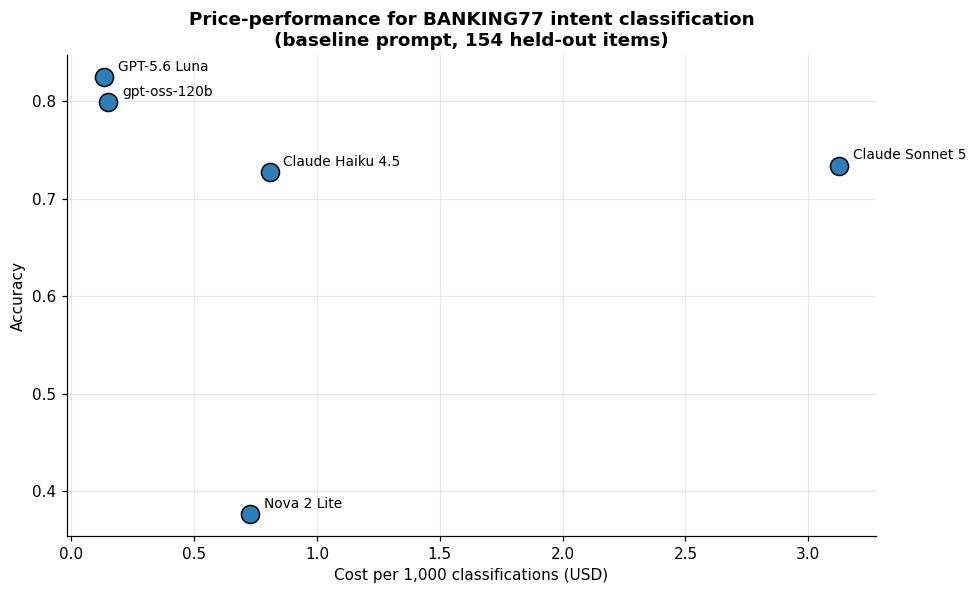

In [15]:
# Cost against accuracy: the price-performance frontier for this workload.
frontier = baseline_table.copy()
ax = frontier.plot.scatter(x="cost/1k", y="accuracy", s=140, figsize=(9, 5.5),
                           color="#2c7fb8", edgecolor="black", zorder=3)
for _, r in frontier.iterrows():
    ax.annotate(r["model"], (r["cost/1k"], r["accuracy"]),
                textcoords="offset points", xytext=(9, 4), fontsize=9)
ax.set_xlabel("Cost per 1,000 classifications (USD)")
ax.set_ylabel("Accuracy")
ax.set_title("Price-performance for BANKING77 intent classification\n"
             "(baseline prompt, 154 held-out items)")
ax.grid(alpha=0.3, zorder=0)
ax.figure.tight_layout()

---

## 5. Wait, is Nova 2 Lite really that bad? (maybe not!)

Nova 2 Lite's score is a trap, and it is worth dismantling because the same trap is sitting in a lot
of production evaluations right now.  **The moral of the story is that when scores are bad, the first thing you check is the evaluation.**

Let's look at what it actually returned.

In [16]:
nova_records = [r for r in baseline_runs[mc.NOVA_2_LITE]["records"] if r.ok]

for rec in nova_records[:3]:
    gold = rec.meta["item"]["label"]
    print(f"gold           : {gold}")
    print(f"graded as      : {b77.normalize_label(rec.text, 'longest')}")
    print(f"response       : {rec.text[:180]!r}")
    print(f"output tokens  : {rec.output_tokens}")
    print("-" * 78)

gold           : lost_or_stolen_card
graded as      : lost_or_stolen_card
response       : '### **Intent:** `lost_or_stolen_card`\n\nThe customer is indicating that they **cannot locate their card** and is seeking guidance on what to do — which aligns with the **`lost_or_st'
output tokens  : 130
------------------------------------------------------------------------------
gold           : why_verify_identity
graded as      : unable_to_verify_identity
response       : '### **Intent Classification: `why_verify_identity`**\n\n---\n\n### **Explanation:**\n\nThe customer is asking about the **ability to use their account before identity verification is com'
output tokens  : 187
------------------------------------------------------------------------------
gold           : terminate_account
graded as      : terminate_account
response       : '### **Intent Classification: `terminate_account`**\n\n---\n\n**Explanation:**\n\nThe customer explicitly states:  \n> *"I want my account deleted!"*\n

Nova 2 Lite is not misclassifying. It frequently names the **correct** intent, then writes a
paragraph of explanation — and that paragraph mentions other intent names. Our parser has to pick
one of them, and the fallback rule decides which. That is a scoring decision masquerading as an
implementation detail.

`banking77.normalize_label` supports two fallback strategies:

- `longest` — prefer the longest matching label. Necessary because `card_not_working` is a
  substring of `virtual_card_not_working`, so a naive search mis-scores those.
- `first` — prefer the earliest-mentioned label. For a chatty model, the first label
  mentioned is usually the actual answer.

Watch what happens when we change only the evaluator, re-scoring the
**exact same responses** with no new Bedrock calls.

In [17]:
rows = []
for model in mc.CANDIDATE_MODELS:
    records = baseline_runs[model]["records"]
    longest = b77.summarize(records, model_id=model, strategy="longest")
    first = b77.summarize(records, model_id=model, strategy="first")
    rows.append({
        "model": mc.friendly(model),
        "longest-match": longest["accuracy"],
        "first-mentioned": first["accuracy"],
        "swing": first["accuracy"] - longest["accuracy"],
        "avg out tokens": longest["avg_output_tokens"],
    })
comparison = pd.DataFrame(rows)
comparison.style.format({"longest-match": "{:.1%}", "first-mentioned": "{:.1%}",
                         "swing": "{:+.1%}", "avg out tokens": "{:.0f}"})

,model,longest-match,first-mentioned,swing,avg out tokens
0,Nova 2 Lite,37.7%,68.8%,+31.2%,208
1,Claude Haiku 4.5,72.7%,72.1%,-0.6%,45
2,Claude Sonnet 5,73.4%,76.0%,+2.6%,48
3,gpt-oss-120b,79.9%,79.9%,+0.0%,123
4,GPT-5.6 Luna,82.5%,82.5%,+0.0%,36


Nova 2 Lite moves dramatically. Same model, same prompt, same responses, same dataset — a
different parsing rule. The models that answer tersely barely move at all, because there is
nothing to misparse.

**Key Learning:**
When evaluation results look low, the first place to look for a problem is in the evaluator. An evaluator is worthless unless it's been evaluated to make sure that it's evaluating correctly.

---

## 6. Let's optimize our workload for each model!

Many companies stop here, picking the top one from the baseline test as their one gold standard model and moving on. This leaves a huge amount of value and capacity on the table. Many of those models that weren't performing quite well enough just need a little tweak to their prompt to bring them up to snuff.

The obvious fix is to write a better prompt. The less obvious part is that **the best prompt
is not the same for every model.** A formatting instruction that rescues a chatty model can
strip the working room from a model that answers better after a moment of reasoning. This may seem like a lot of work, but Bedrock's Advanced Prompt Optimization (AdvPO) does this for us automatically. 

AdvPO is the right tool for this module. It optimizes one template against all five target
models in a single job, it is steered by a metric *we* define, and it reports cost and latency
per model — which is exactly the information a routing decision needs.

### Why this notebook does not run the job

An AdvPO job is asynchronous and takes 15 minutes to several hours. That does not fit in a
notebook cell. So the job was run once, for real, by
[`scripts/run_advpo_job.py`](scripts/run_advpo_job.py), and its actual output is committed to
`data/advpo_results.jsonl`.

Everything below is the real setup code, which you can use to run your own jobs. The only thing we skip in this workshop is the waiting!

### Step 1: prepare the input dataset

AdvPO takes a JSONL file, one line per prompt template. The fields that matter:

| Field | Purpose |
|---|---|
| `version` | fixed schema version string |
| `templateId` | your identifier, used to correlate input with output |
| `promptTemplate` | the prompt, with `{{variable}}` placeholders |
| `evaluationSamples` | 1-100 samples, each with `inputVariables` and a `referenceResponse` |
| `customEvaluationMetricLabel` | a name for your metric |
| `evaluationMetricLambdaArn` | your scoring function, if you use one |

Three things that are easy to get wrong:

- `inputVariables` must be a **list of single-key objects**: `[{"a": "1"}, {"b": "2"}]`.
  Putting several keys in one object fails **silently**.
- Placeholders use **double** braces. `{variable}` is not a placeholder.
- Optimization samples should be **held out from your evaluation set**, or you are measuring
  memorisation. Ours come from the BANKING77 *train* split while the evaluation set comes from
  the *test* split, with zero overlap.

### Scoping what gets rewritten

By default AdvPO may rewrite your entire template. Two tags scope that:

- `<advpo:optimize>` marks the **only** regions the optimizer may rewrite — mark what *is*
  optimizable with this tag.
- `<advpo:exclude>` marks regions it must leave alone — use this to protect a section, such as a
  fixed label vocabulary, from being paraphrased.

We submit two variants to see how much that scoping matters in practice:

| Template | Tagging | What the optimizer may change |
|---|---|---|
| `banking77-free` | none | anything, including how the labels are presented |
| `banking77-scoped` | `<advpo:optimize>` around the instructions | the instructions only; labels and placeholder preserved |

A job accepts up to 10 templates and up to 5 models, and optimizes **every template for every
model** — so this comparison costs one job, not two.

In [18]:
optimizer_samples = b77.load_optimizer_samples()
eval_texts = {i["text"] for i in EVAL_SET}

print(f"optimizer samples : {len(optimizer_samples)} (AdvPO limit is 100 per template)")
print(f"evaluation items  : {len(EVAL_SET)}")
print(f"overlap           : {len(eval_texts & {s['text'] for s in optimizer_samples})} items")
print()

evaluation_samples = [
    {"inputVariables": [{"customerMessage": s["text"]}],
     "referenceResponse": s["label"]}
    for s in optimizer_samples
]

advpo_input = [
    {
        "version": mc.ADVPO_INPUT_VERSION,
        "templateId": template_id,
        "promptTemplate": template,
        "customEvaluationMetricLabel": "banking77_exact_and_terse",
        "evaluationSamples": evaluation_samples,
    }
    for template_id, template in [
        ("banking77-free", b77.ADVPO_TEMPLATE_FREE),
        ("banking77-scoped", b77.ADVPO_TEMPLATE_SCOPED),
    ]
]

print("first evaluation sample as AdvPO sees it:")
print(json.dumps(evaluation_samples[0], indent=2))
print()
for record in advpo_input:
    print(f"template {record['templateId']:<20} {len(record['promptTemplate']):>5} chars  "
          f"optimize-tagged={'<advpo:optimize>' in record['promptTemplate']}")

optimizer samples : 77 (AdvPO limit is 100 per template)
evaluation items  : 154
overlap           : 0 items

first evaluation sample as AdvPO sees it:
{
  "inputVariables": [
    {
      "customerMessage": "Someone has copied my card. I have my card with me, but someone just made a 500\u00a3 cash withdrawal. Please help now."
    }
  ],
  "referenceResponse": "cash_withdrawal_not_recognised"
}

template banking77-free        1833 chars  optimize-tagged=False
template banking77-scoped      1880 chars  optimize-tagged=True


In [19]:
# The scoped variant, with the label block collapsed for readability. Only the
# text inside <advpo:optimize> is eligible to be rewritten.
def collapse_labels(text):
    kept, skipped = [], 0
    for line in text.split("\n"):
        if line.strip() in b77.LABELS:
            skipped += 1
            continue
        if skipped:
            kept.append(f"        ... {skipped} intent labels ...")
            skipped = 0
        kept.append(line)
    if skipped:
        kept.append(f"        ... {skipped} intent labels ...")
    return "\n".join(kept)

print(collapse_labels(b77.ADVPO_TEMPLATE_SCOPED))

<advpo:optimize>You are a customer service assistant for a digital bank.
Classify the customer's message into one of the intents listed below.
Give the intent as your answer.</advpo:optimize>

        ... 77 intent labels ...

Customer message: {{customerMessage}}


### Step 2: choose an evaluation method

AdvPO offers four ways to score candidate prompts: a built-in default judge, natural-language
steering criteria, a custom LLM-as-a-judge rubric, or **your own Lambda function**.

For this task we use a lambda because we just need a simple string match. Many evaluation tasks are best served by an LLM as a judge. This is a powerful technique, but requires you to first evaluate your judge prompt itself to make sure the judge is judging correctly. You can reference the foundation modules in this workshop to learn more about judging a judge. 

Our scorer is in [`scripts/lambda_evaluator.py`](scripts/lambda_evaluator.py). It does not
just check correctness — it rewards being correct **and terse**:

| Score | Condition |
|---|---|
| 1.0 | the response is exactly the right label and nothing else |
| 0.6 | the right label, but wrapped in explanation we would have to parse out |
| 0.0 | wrong label, or no recognisable label |

That partial-credit tier is deliberate. AdvPO maximises the average score, so a continuous
metric gives it a gradient to follow rather than an all-or-nothing cliff. It also encodes the
finding from section 5: burying a correct answer in prose is a real defect, not a cosmetic one.

 if using LLM as a judge, this is a great place to compute your true/false statements into a continuous score, as described in the foundation modules in this workshop.

One non-obvious requirement: **AdvPO reads your metric's source code and docstring** to understand what the metric rewards, and uses that to generate better feedback. Clear naming and a real docstring are functional, not decorative.

### Step 3: Submit the job

For this workshop, we've already run the job and saved the results for you. The job can take anywhere from 15 minutes to a few hours to run. Set `RUN_ADVPO_JOB = True` only if you want to spend the money and wait. Note it also needs
`boto3>=1.43`, a writable S3 bucket, and the Lambda deployed.

In [21]:
RUN_ADVPO_JOB = False   # the results are already committed under data/

model_configurations = [
    {"modelId": mc.ADVPO_MODEL_IDS[m], "inferenceConfig": {"maxTokens": 1024}}
    for m in mc.CANDIDATE_MODELS
]
for runtime_id, cfg in zip(mc.CANDIDATE_MODELS, model_configurations):
    note = "" if cfg["modelId"] == runtime_id else f"   <- differs from runtime id {runtime_id}"
    print(f"{cfg['modelId']:<46}{note}")

if RUN_ADVPO_JOB:
    import boto3
    bedrock = boto3.client("bedrock", region_name=mc.REGION)
    response = bedrock.create_advanced_prompt_optimization_job(
        jobName="capacity-mgmt-banking77",
        inputConfig={"s3Uri": "s3://YOUR-BUCKET/advpo/input/banking77_templates.jsonl"},
        outputConfig={"s3Uri": "s3://YOUR-BUCKET/advpo/output/"},
        modelConfigurations=model_configurations,
    )
    job_arn = response["jobArn"]
    print(f"submitted {job_arn}")
    # Then poll get_advanced_prompt_optimization_job(jobIdentifier=job_arn)
    # until jobStatus is terminal, and read
    #   <output s3Uri>/<job-id>/advanced_prompt_optimization_results.jsonl
else:
    print("\nskipping submission; loading the committed results instead")

us.amazon.nova-2-lite-v1:0                    
us.anthropic.claude-haiku-4-5-20251001-v1:0   
us.anthropic.claude-sonnet-5                  
openai.gpt-oss-120b-1:0                       
openai.gpt-5.6-luna                              <- differs from runtime id us.openai.gpt-5.6-luna

skipping submission; loading the committed results instead


### Step 4: read the results

Results land at `<output-s3-uri>/<job-id>/advanced_prompt_optimization_results.jsonl`, one
line per template.  Each per-model
entry carries:

| Field | Contents |
|---|---|
| `modelId` | the target model, in AdvPO's ID form |
| `status` | `SUCCESS`, or a `failureReason` |
| `optimizedPromptTemplate` | the rewritten prompt |
| `originalPromptMetrics` | score, tokens, TTFT and latency **before** optimization |
| `optimizedPromptMetrics` | the same measurements **after** |
| `dataset` | every evaluation sample with both model responses |

In [22]:
with open("data/advpo_results.jsonl") as f:
    advpo_results = [json.loads(line) for line in f if line.strip()]

print(f"templates in results : {len(advpo_results)}")
print(f"top-level fields     : {sorted(advpo_results[0].keys())}")

first_entry = advpo_results[0]["promptOptimizationResults"][0]
print(f"per-model fields     : {sorted(first_entry.keys())}")
print(f"metric fields        : {sorted(first_entry['optimizedPromptMetrics'].keys())}")
print(f"samples per entry    : {len(first_entry['dataset'])}")
print()
for line in advpo_results:
    statuses = {e["status"] for e in line["promptOptimizationResults"]}
    print(f"  {line['promptTemplateId']:<22} "
          f"{len(line['promptOptimizationResults'])} models, status {statuses}")

templates in results : 2
top-level fields     : ['customEvaluationMetricLabel', 'evaluationMetricLambdaArn', 'promptOptimizationResults', 'promptTemplate', 'promptTemplateId']
per-model fields     : ['dataset', 'modelId', 'optimizedPromptMetrics', 'optimizedPromptTemplate', 'optimizedPromptTemplateId', 'originalPromptMetrics', 'status']
metric fields        : ['averageInputTokens', 'averageLatencyInSec', 'averageOutputTokens', 'averageScore', 'averageTtftInSec', 'medianLatencyInSec', 'medianTtftInSec']
samples per entry    : 77

  banking77-free         5 models, status {'SUCCESS'}
  banking77-scoped       5 models, status {'SUCCESS'}


In [23]:
# AdvPO's own before/after scores, for every template x model combination.
# Score is our Lambda metric: 1.0 for the bare correct label, 0.6 if the correct
# label is buried in prose, 0.0 if wrong.
rows = []
for line in advpo_results:
    for entry in line["promptOptimizationResults"]:
        runtime_id = mc.RUNTIME_MODEL_IDS.get(entry["modelId"], entry["modelId"])
        before, after = entry["originalPromptMetrics"], entry["optimizedPromptMetrics"]
        rows.append({
            "template": line["promptTemplateId"],
            "model": mc.friendly(runtime_id),
            "score before": before["averageScore"],
            "score after": after["averageScore"],
            "delta": after["averageScore"] - before["averageScore"],
            "out tok before": before["averageOutputTokens"],
            "out tok after": after["averageOutputTokens"],
            "ttft after (s)": after["averageTtftInSec"],
            "rewritten": entry["optimizedPromptTemplate"] != line["promptTemplate"],
        })

advpo_scores = pd.DataFrame(rows)
advpo_scores.style.format({
    "score before": "{:.3f}", "score after": "{:.3f}", "delta": "{:+.3f}",
    "out tok before": "{:.0f}", "out tok after": "{:.0f}",
    "ttft after (s)": "{:.2f}"}).background_gradient(subset=["delta"], cmap="RdYlGn")

,template,model,score before,score after,delta,out tok before,out tok after,ttft after (s),rewritten
0,banking77-free,Nova 2 Lite,0.273,0.766,+0.494,208,6,0.37,True
1,banking77-free,Claude Haiku 4.5,0.506,0.909,+0.403,42,6,0.68,True
2,banking77-free,Claude Sonnet 5,0.675,0.909,+0.234,42,10,1.35,True
3,banking77-free,gpt-oss-120b,0.855,0.987,+0.132,112,117,0.38,True
4,banking77-free,GPT-5.6 Luna,0.909,0.935,+0.026,35,29,0.36,True
5,banking77-scoped,Nova 2 Lite,0.382,0.779,+0.397,114,6,0.37,True
6,banking77-scoped,Claude Haiku 4.5,0.795,0.813,+0.018,8,9,0.69,True
7,banking77-scoped,Claude Sonnet 5,0.813,0.857,+0.044,10,21,1.54,True
8,banking77-scoped,gpt-oss-120b,0.883,0.987,+0.104,109,149,0.41,True
9,banking77-scoped,GPT-5.6 Luna,0.870,0.896,+0.026,34,39,0.48,True


In [24]:
# For each model, adopt the template from whichever variant AdvPO scored highest.
# This is still AdvPO's own opinion, measured on the optimizer's samples -- we
# verify it independently on held-out data in the next section.
OPTIMIZED_TEMPLATES = {}
selection = []

for model in mc.CANDIDATE_MODELS:
    advpo_id = mc.ADVPO_MODEL_IDS[model]
    candidates = []
    for line in advpo_results:
        for entry in line["promptOptimizationResults"]:
            if entry["modelId"] != advpo_id or entry["status"] != "SUCCESS":
                continue
            candidates.append({
                "template_id": line["promptTemplateId"],
                "prompt": entry["optimizedPromptTemplate"],
                "score": entry["optimizedPromptMetrics"]["averageScore"],
                "baseline_score": entry["originalPromptMetrics"]["averageScore"],
            })
    if not candidates:
        print(f"no successful optimization for {mc.friendly(model)}")
        continue
    best = max(candidates, key=lambda c: c["score"])
    OPTIMIZED_TEMPLATES[model] = best["prompt"]
    selection.append({
        "model": mc.friendly(model),
        "variant chosen": best["template_id"],
        "advpo score": best["score"],
        "advpo baseline": best["baseline_score"],
        "labels intact": sum(1 for l in b77.LABELS if l in best["prompt"]),
        "prompt chars": len(best["prompt"]),
    })

print(f"optimized templates selected: {len(OPTIMIZED_TEMPLATES)}/{len(mc.CANDIDATE_MODELS)}\n")
pd.DataFrame(selection)

optimized templates selected: 5/5



,model,variant chosen,advpo score,advpo baseline,labels intact,prompt chars
0,Nova 2 Lite,banking77-scoped,0.779221,0.381818,77,4395
1,Claude Haiku 4.5,banking77-free,0.909091,0.506494,77,6119
2,Claude Sonnet 5,banking77-free,0.909091,0.675325,77,6031
3,gpt-oss-120b,banking77-free,0.987013,0.854545,77,9877
4,GPT-5.6 Luna,banking77-free,0.935065,0.909091,77,3904


The `labels intact` column is a guardrail. The unrestricted variant is allowed
to rewrite the label list, and a rewrite that renames or drops intents would score terribly while
looking like a valid prompt. Both variants came back with all 77 labels intact for every model, so
the `<advpo:optimize>`/`<advpo:exclude>` scoping did what it was supposed to do: whatever else
changed, the label vocabulary was untouched.

In most cases, `free` won, as we gave the optimizer more space to play with and more opportunity to creatively improve the prompt. `free` had the whole prompt to work with, including the boundary between the
instructions and the label list, and used that room to add the same kind of output-format
contracts and disambiguation rules we saw pay off in section 5 — just with more to work with than
three sentences. A tag that scopes the optimizer to a tiny, low-information region can end up
scoping it out of doing anything useful at all.

Note that this is a real finding about *this* task, not a rule that unrestricted optimization always wins.

In [55]:
# Let's take a look at an example of what the optimizer actually changed.
inspect_model = mc.NOVA_2_LITE if mc.NOVA_2_LITE in OPTIMIZED_TEMPLATES \
    else next(iter(OPTIMIZED_TEMPLATES))

print(f"OPTIMIZED PROMPT FOR {mc.friendly(inspect_model)}")
print("=" * 78)
print(collapse_labels(OPTIMIZED_TEMPLATES[inspect_model]))

OPTIMIZED PROMPT FOR Nova 2 Lite
You are an intent classification engine for a digital bank.

OUTPUT CONTRACT (mandatory): Respond with ONLY the single most appropriate intent label from the list below. Your entire response must be exactly one label — no markdown, no asterisks, no headers, no backticks, no punctuation, no explanation, no reasoning, and no additional words of any kind. Do not mention any other label names in your response. A single bare label on a single line is the only acceptable output.

CORRECT example output: pending_transfer
WRONG example output: ### Intent: `pending_transfer` — The customer is asking about...

CRITICAL DISTINCTIONS for easily confused intents:
- Use `cash_withdrawal_not_recognised` when a customer reports a cash withdrawal transaction they did not make or do not recognise — even if they explicitly say their card was cloned, copied, or compromised AND there is a specific cash withdrawal they are disputing. The unrecognised transaction is ALWAYS th

---

## 7. Did the optimization actually help?

**Never accept an optimized prompt on faith.** An optimizer maximises the metric you gave it
on the samples you gave it. That is not the same as improving your workload, and prompt
rewrites can break output contracts in ways a score does not surface.

So let's re-run the identical 154-item held-out evaluation, with each model now using the prompt
optimized specifically for it, and compare against the baseline.

In [27]:
# prompt_fn receives the model ID, which is what lets one workload run with a
# different prompt per model.
def optimized_prompt(item, model_id):
    template = OPTIMIZED_TEMPLATES.get(model_id, b77.BASELINE_TEMPLATE)
    return b77.render_prompt(template, item["text"])

optimized_runs = {}
for model in mc.CANDIDATE_MODELS:
    label = "optimized" if model in OPTIMIZED_TEMPLATES else "baseline (no optimized prompt)"
    print(f"{mc.friendly(model)} [{label}] ...", flush=True)
    eval_router.reset()
    result = run_workload(eval_router, EVAL_SET, optimized_prompt,
                          model=model, max_workers=12, max_tokens=1024,
                          progress=False)
    optimized_runs[model] = result
    s = b77.summarize(result["records"], model_id=model)
    print(f"   accuracy {s['accuracy']:>6.1%}   "
          f"cost/1k ${s['cost_per_1k_usd']:>6.3f}   "
          f"p50 {s['latency_p50_s']:>4.2f}s   "
          f"avg out {s['avg_output_tokens']:>5.0f} tok   "
          f"unparsed {s['unparsed']:>2}")

Nova 2 Lite [optimized] ...
   accuracy  70.1%   cost/1k $ 0.345   p50 0.49s   avg out     6 tok   unparsed  2
Claude Haiku 4.5 [optimized] ...
   accuracy  76.0%   cost/1k $ 1.660   p50 1.00s   avg out     8 tok   unparsed  1
Claude Sonnet 5 [optimized] ...
   accuracy  78.6%   cost/1k $ 7.008   p50 1.54s   avg out    12 tok   unparsed  1
gpt-oss-120b [optimized] ...
   accuracy  83.8%   cost/1k $ 0.408   p50 0.95s   avg out   125 tok   unparsed  2
GPT-5.6 Luna [optimized] ...
   accuracy  80.5%   cost/1k $ 0.213   p50 1.71s   avg out    33 tok   unparsed  2


In [28]:
rows = []
for model in mc.CANDIDATE_MODELS:
    before = b77.summarize(baseline_runs[model]["records"], model_id=model)
    after = b77.summarize(optimized_runs[model]["records"], model_id=model)
    rows.append({
        "model": mc.friendly(model),
        "accuracy before": before["accuracy"],
        "accuracy after": after["accuracy"],
        "accuracy delta": after["accuracy"] - before["accuracy"],
        "in tok before": before["avg_input_tokens"],
        "in tok after": after["avg_input_tokens"],
        "out tok before": before["avg_output_tokens"],
        "out tok after": after["avg_output_tokens"],
        "cost/1k before": before["cost_per_1k_usd"],
        "cost/1k after": after["cost_per_1k_usd"],
    })
before_after = pd.DataFrame(rows).sort_values("accuracy after", ascending=False)
before_after = before_after.reset_index(drop=True)
before_after.style.format({
    "accuracy before": "{:.1%}", "accuracy after": "{:.1%}",
    "accuracy delta": "{:+.1%}",
    "in tok before": "{:.0f}", "in tok after": "{:.0f}",
    "out tok before": "{:.0f}", "out tok after": "{:.0f}",
    "cost/1k before": "${:.3f}", "cost/1k after": "${:.3f}",
}).background_gradient(subset=["accuracy delta"], cmap="RdYlGn")

,model,accuracy before,accuracy after,accuracy delta,in tok before,in tok after,out tok before,out tok after,cost/1k before,cost/1k after
0,gpt-oss-120b,79.9%,83.8%,+3.9%,508,2218,123,125,$0.150,$0.408
1,GPT-5.6 Luna,82.5%,80.5%,-1.9%,447,867,36,33,$0.132,$0.213
2,Claude Sonnet 5,73.4%,78.6%,+5.2%,800,2276,48,12,$3.124,$7.008
3,Claude Haiku 4.5,72.7%,76.0%,+3.2%,582,1618,45,8,$0.807,$1.660
4,Nova 2 Lite,37.7%,70.1%,+32.5%,474,993,208,6,$0.728,$0.345


Note that optimization often involves increasing the size of the input prompt. This does mean an increase in costs, but keep in mind that, in general, input tokens are much cheaper than output tokens. Keep in mind as well that, in most real use cases, input tokens can be cached, resulting in a massive cost reduction. Here we look at the raw numbers with no caching. 

**Note** For simplicity, we're using a sample workload that has exact matches. However, it's common to see much more impact from the optimization jobs where tasks are complex and require an LLM as a judge. 

Next, we grab the best prompt from each version that we tested and store those as "production prompts" 

In [30]:
PRODUCTION_PROMPTS = {}
decisions = []

for model in mc.CANDIDATE_MODELS:
    before = b77.summarize(baseline_runs[model]["records"], model_id=model)
    after = b77.summarize(optimized_runs[model]["records"], model_id=model)
    use_optimized = (model in OPTIMIZED_TEMPLATES
                     and after["accuracy"] > before["accuracy"])
    PRODUCTION_PROMPTS[model] = (OPTIMIZED_TEMPLATES[model] if use_optimized
                                 else b77.BASELINE_TEMPLATE)
    chosen = after if use_optimized else before
    decisions.append({
        "model": mc.friendly(model),
        "prompt adopted": "optimized" if use_optimized else "baseline",
        "accuracy": chosen["accuracy"],
        "cost/1k": chosen["cost_per_1k_usd"],
        "p50 latency (s)": chosen["latency_p50_s"],
    })

final = pd.DataFrame(decisions).sort_values("accuracy", ascending=False)
final = final.reset_index(drop=True)
final.style.format({"accuracy": "{:.1%}", "cost/1k": "${:.3f}",
                    "p50 latency (s)": "{:.2f}"})

,model,prompt adopted,accuracy,cost/1k,p50 latency (s)
0,gpt-oss-120b,optimized,83.8%,$0.408,0.95
1,GPT-5.6 Luna,baseline,82.5%,$0.132,1.26
2,Claude Sonnet 5,optimized,78.6%,$7.008,1.54
3,Claude Haiku 4.5,optimized,76.0%,$1.660,1.00
4,Nova 2 Lite,optimized,70.1%,$0.345,0.49


### The quality bar

The quality cutoff is a business decision. Every company has to decide how much it wants to pay for quality. Many times, at the start of a project, an engineer might think, "I want 100% quality," but when the difference between 100% and 99% is $1 million a year, suddenly 99% quality doesn't seem so bad. In the same way, now that we have many different options at different performance, place, and cost points, we can decide the trade-off for a particular workload which best meets our business needs.

In [56]:
QUALITY_BAR = 0.75     # try moving this and watch the capacity ceiling change

capacity_rows = []
for _, row in final.iterrows():
    model = next(m for m in mc.CANDIDATE_MODELS if mc.friendly(m) == row["model"])
    capacity_rows.append({
        "model": row["model"],
        "accuracy": row["accuracy"],
        "simulated RPM": mc.DEMO_QUOTAS[model],
        "example RPM quota": mc.PRODUCTION_QUOTAS_EXAMPLE[model],
        "passes bar": row["accuracy"] >= QUALITY_BAR,
    })
capacity_df = pd.DataFrame(capacity_rows)

passing = capacity_df[capacity_df["passes bar"]]
list_cap = int(passing["example RPM quota"].sum())

# What a single-model workload gets: the one model you would have shipped if the
# evaluation had simply ranked the candidates and picked a winner.
winner = passing.sort_values("accuracy", ascending=False).iloc[0]
single_cap = int(winner["example RPM quota"])

display(capacity_df.style.format({"accuracy": "{:.1%}"}))

print(f"\nQuality bar: {QUALITY_BAR:.0%} accuracy")
print(f"Models admitted: {int(capacity_df['passes bar'].sum())}/{len(capacity_df)}")
print()
print("QUALITY-WEIGHTED CAPACITY (using the example quota table)")
print(f"   one model, {winner['model']:<16} : {single_cap:>6,} RPM")
print(f"   every model that clears the bar : {list_cap:>6,} RPM")
print(f"   change                          : {list_cap - single_cap:>+6,} RPM "
      f"({(list_cap / single_cap - 1):+.0%})")

,model,accuracy,simulated RPM,example RPM quota,passes bar
0,gpt-oss-120b,83.8%,6,400,True
1,GPT-5.6 Luna,82.5%,6,400,True
2,Claude Sonnet 5,78.6%,6,100,True
3,Claude Haiku 4.5,76.0%,6,100,True
4,Nova 2 Lite,70.1%,6,100,False


Quality bar: 75% accuracy
Models admitted: 4/5

QUALITY-WEIGHTED CAPACITY (using the example quota table)
   one model, gpt-oss-120b     :    400 RPM
   every model that clears the bar :  1,000 RPM
   change                          :   +600 RPM (+150%)


Here is that result as a picture. The left panel is the quality decision, the right panel is the
capacity it buys.

![Two-panel chart. Left panel, titled "Who clears the quality bar?": a slope chart of accuracy on 154 held-out items, moving from the baseline prompt to each model's adopted prompt, with a dashed line at the 75% quality bar. gpt-oss-120b rises from 79.9% to 83.8% and GPT-5.6 Luna holds at 82.5%, both already above the bar; Claude Sonnet 5 crosses from 73.4% to 78.6% and Claude Haiku 4.5 from 72.7% to 76.0%; Nova 2 Lite improves sharply from 37.7% to 70.1% but stays below the bar. Right panel, titled "One model, or every model that qualifies": two stacked bars comparing the requests-per-minute quota available in each situation. Running the single best model gives 400 RPM. Running every model that clears the bar gives 1,000 RPM — gpt-oss-120b 400, GPT-5.6 Luna 400, and Claude Sonnet 5 and Claude Haiku 4.5 contributing 100 each, both admitted only after prompt optimization. An arrow marks the increase as +150% with no quota increase requested.](images/fig5-quality-weighted-capacity-hero.png)

That number is the payoff. Asking *"which models will work?"* instead of *"which model is best?"*
changed **how much traffic this workload can serve at acceptable quality**, without a single
quota increase request.

Prompt optimization is what made the difference between two models clearing the bar and four.
Every model it lifts over the bar brings its whole quota with it, which is why optimization is a
capacity lever and not just a quality lever.

Notice what would have happened if we had stopped after section 4 and simply picked the best
model: we would have shipped one model, ignored the rest, and capped ourselves at that model's
quota.

---

## 8. Putting it together: capacity-aware routing

Everything is now in place to build the router:

1. A **priority order**, derived from measurement rather than intuition
2. A **per-model prompt map**, so each model gets the prompt it was tuned for
3. A **queueing limiter** that spends quota from whichever model has it

### Admission needs a cost ceiling too, not just a quality bar

A quality bar alone produces a bad portfolio here. Claude Sonnet 5 clears 75% accuracy, so the
bar admits it — but at $7.008 per 1,000 classifications it costs more than 53x the cheapest
admitted model, for *lower* accuracy. Adding it to the routing table would buy a little capacity
at a wildly disproportionate price.

So admission takes two tests: accuracy at or above the quality bar, **and** cost at or below a
fixed dollar-per-1,000 ceiling. A flat number rather than a multiple of "whatever the cheapest
admitted model happens to cost" is deliberate. Which model is cheapest can change from one
evaluation run to the next — a model gets deprecated, a new one launches, a price changes. A constant threshold for quality and cost gives you predictable results.

**Note:**  Depending on the workload, it may also be appropriate to add a P50 latency threshold as well.

In [57]:
COST_CEILING_USD_PER_1K = 2.00   # a flat cap in dollars, 

quality_ok = final[final["accuracy"] >= QUALITY_BAR].copy()
quality_ok["admitted"] = quality_ok["cost/1k"] <= COST_CEILING_USD_PER_1K

print(f"quality bar   : {QUALITY_BAR:.0%} accuracy")
print(f"cost ceiling  : ${COST_CEILING_USD_PER_1K:.2f} per 1,000 classifications\n")
for _, row in quality_ok.sort_values("cost/1k").iterrows():
    verdict = "admitted" if row["admitted"] else "REJECTED (too expensive)"
    print(f"  {row['model']:<20} accuracy {row['accuracy']:.1%}  "
          f"cost/1k ${row['cost/1k']:.3f}  {verdict}")

admitted = quality_ok[quality_ok["admitted"]].copy()
admitted["accuracy per dollar"] = admitted["accuracy"] / admitted["cost/1k"]
admitted = admitted.sort_values("accuracy per dollar", ascending=False)

PRIORITY_ORDER = [
    next(m for m in mc.CANDIDATE_MODELS if mc.friendly(m) == name)
    for name in admitted["model"]
]

print(f"\nrouting priority order ({len(PRIORITY_ORDER)} models):")
for rank, model in enumerate(PRIORITY_ORDER, 1):
    row = admitted[admitted["model"] == mc.friendly(model)].iloc[0]
    prompt_kind = ("optimized" if PRODUCTION_PROMPTS[model] != b77.BASELINE_TEMPLATE
                   else "baseline")
    print(f"  {rank}. {mc.friendly(model):<20} accuracy {row['accuracy']:.1%}  "
          f"cost/1k ${row['cost/1k']:.3f}  prompt: {prompt_kind}")

print(f"\naggregate simulated quota: "
      f"{sum(mc.DEMO_QUOTAS[m] for m in PRIORITY_ORDER)} RPM "
      f"across {len(PRIORITY_ORDER)} models")
admitted[["model", "accuracy", "cost/1k", "p50 latency (s)", "accuracy per dollar"]]

quality bar   : 75% accuracy
cost ceiling  : $2.00 per 1,000 classifications

  GPT-5.6 Luna         accuracy 82.5%  cost/1k $0.132  admitted
  gpt-oss-120b         accuracy 83.8%  cost/1k $0.408  admitted
  Claude Haiku 4.5     accuracy 76.0%  cost/1k $1.660  admitted
  Claude Sonnet 5      accuracy 78.6%  cost/1k $7.008  REJECTED (too expensive)

routing priority order (3 models):
  1. GPT-5.6 Luna         accuracy 82.5%  cost/1k $0.132  prompt: baseline
  2. gpt-oss-120b         accuracy 83.8%  cost/1k $0.408  prompt: optimized
  3. Claude Haiku 4.5     accuracy 76.0%  cost/1k $1.660  prompt: optimized

aggregate simulated quota: 18 RPM across 3 models


,model,accuracy,cost/1k,p50 latency (s),accuracy per dollar
1,GPT-5.6 Luna,0.824675,0.132213,1.264000,6.237476
0,gpt-oss-120b,0.837662,0.407776,0.953391,2.054222
3,Claude Haiku 4.5,0.759740,1.660357,1.000227,0.457576


Ranking by accuracy per dollar puts the cheapest strong model first, so the expensive fallbacks
only ever see **overflow** traffic. The right ranking depends on your binding constraint though:
sort on p50 latency if you are latency-sensitive, or on cost per 1,000 if cost dominates.

### Want more models on the list? Make the task easier

Some candidates did not make it, and it is worth noticing *why*. They failed because the task, as
posed, is hard enough to need a strong model. But "the task" is a choice, not a fact.

A single complicated prompt sets a high bar that only expensive models can clear. Break the same
work into a few smaller steps and each step is individually much easier, which means cheaper models
can pass the bar on each one — and some steps may not need a model at all. That directly grows the
number of candidates meeting your price-performance criteria, and therefore grows quality-weighted
capacity, without touching a single quota.

For example, this workload might consider breaking this single prompt with 77 possible intents into three separate prompts, each with a list of a third of the possible intents. While sending three prompts instead of one may seem counterintuitive, the three can be sent in parallel and are roughly the same amount of tokens as the one large prompt. They actually end up being roughly the same cost and often lower latency. The real gain here, though, is that the individual smaller prompts often work great on smaller models, meaning we can massively reduce costs by shifting what previously couldn't run on a smaller model into three queries on a smaller model. 

### Let's make it real

Now we rerun the exact workload from section 3 — the same 24 requests, the same 6 RPM per model
— but routed across the admitted models with each model's own prompt.

In [34]:
def production_prompt(item, model_id):
    return b77.render_prompt(PRODUCTION_PROMPTS[model_id], item["text"])

routed_router = CapacityRouter(quotas=mc.DEMO_QUOTAS, region=mc.REGION, mode="queue")
routed = run_workload(routed_router, BURST_ITEMS, production_prompt,
                      models=PRIORITY_ORDER, max_workers=12, max_tokens=1024,
                      progress=False)

routed_summary = b77.summarize(routed["records"])
print(f"wall clock      : {routed['wall_clock_s']:.1f}s")
print(f"served          : {routed_summary['n_scored']}/{len(BURST_ITEMS)}")
print(f"accuracy        : {routed_summary['accuracy']:.1%}")
print(f"mean queue wait : {routed_summary['queue_wait_mean_s']:.1f}s")
print(f"cost per 1k     : ${routed_summary['cost_per_1k_usd']:.3f}  (blended)")
print()
print("where the traffic went:")
for model, count in sorted(routed_summary["per_model_counts"].items(),
                           key=lambda kv: -kv[1]):
    print(f"   {mc.friendly(model):<20} {count:>3} requests")
print()
print("fallback depth (0 = first choice in the priority list):")
for depth, count in routed_summary["fallback_depths"].items():
    print(f"   choice {depth + 1}: {count:>3} requests")

wall clock      : 22.5s
served          : 24/24
accuracy        : 79.2%
mean queue wait : 3.5s
cost per 1k     : $0.733  (blended)

where the traffic went:
   GPT-5.6 Luna           8 requests
   gpt-oss-120b           8 requests
   Claude Haiku 4.5       8 requests

fallback depth (0 = first choice in the priority list):
   choice 1:   8 requests
   choice 2:   8 requests
   choice 3:   8 requests


Saturating like this is the worst case, not the normal case. At partial load the router keeps
choosing the cheapest model first and never reaches the expensive fallbacks. `simulate_routing`
lets us test blended cost as a function of offered load without hitting Bedrock.

In [58]:
# Per-model cost and accuracy, taken from the 154-item held-out evaluation
cost_by_model, accuracy_by_model = {}, {}
for _, row in admitted.iterrows():
    model = next(m for m in mc.CANDIDATE_MODELS if mc.friendly(m) == row["model"])
    cost_by_model[model] = row["cost/1k"]
    accuracy_by_model[model] = row["accuracy"]

quotas = {m: mc.DEMO_QUOTAS[m] for m in PRIORITY_ORDER}
aggregate_rpm = sum(quotas.values())

rows = []
for load_pct in (25, 50, 75, 100, 150, 200):
    n = max(1, int(aggregate_rpm * load_pct / 100))
    sim = simulate_routing(n, quotas, priority=PRIORITY_ORDER,
                           service_time_s=0.0, concurrency=n)
    served = sim["served"] or 1
    counts = sim["per_model_counts"]
    blended_cost = sum(cost_by_model[m] * c for m, c in counts.items()) / served
    blended_acc = sum(accuracy_by_model[m] * c for m, c in counts.items()) / served
    rows.append({
        "offered load": f"{load_pct}% of {aggregate_rpm} RPM",
        "requests": n,
        "first choice share": counts.get(PRIORITY_ORDER[0], 0) / served,
        "models used": len(counts),
        "queue wait mean (s)": round(sim["queue_wait_mean_s"], 1),
        "blended cost/1k": blended_cost,
        "expected accuracy": blended_acc,
    })

load_curve = pd.DataFrame(rows)
load_curve.style.format({"first choice share": "{:.0%}",
                         "blended cost/1k": "${:.3f}",
                         "expected accuracy": "{:.1%}",
                         "queue wait mean (s)": "{:.1f}"})

,offered load,requests,first choice share,models used,queue wait mean (s),blended cost/1k,expected accuracy
0,25% of 18 RPM,4,100%,1,0.0,$0.132,82.5%
1,50% of 18 RPM,9,67%,2,0.0,$0.224,82.9%
2,75% of 18 RPM,13,46%,3,0.0,$0.377,82.6%
3,100% of 18 RPM,18,33%,3,0.0,$0.733,80.7%
4,150% of 18 RPM,27,33%,3,1.1,$0.733,80.7%
5,200% of 18 RPM,36,33%,3,1.7,$0.733,80.7%


Let's put both axes of that tradeoff on one chart, along with where the router actually sends
traffic at each load level. This is the shape to keep in your head when someone asks whether a
portfolio "costs more".

![Two-panel chart. Top panel is a line graph showing cost rising only when fallbacks are actually needed. Bottom panel shows a stacked bar graph indicating which models traffic is being routed to as traffic volume continue to increase beyond what one model can handle.](images/fig3-load-curve.png)

- **Below capacity**, essentially all traffic lands on your cheapest acceptable model, so unit
  cost and accuracy are that model's. The fallbacks cost nothing because they are never used.
- **At and above capacity**, the fallbacks engage. Blended cost climbs toward the portfolio
  average, expected accuracy drifts toward it too, and queue wait appears once even the
  fallbacks run dry.

---

## 9. So what did all of that buy us?

Same workload, same models, same quota. The only differences are a prompt optimized per model
and a router that knows where the capacity is.

In [38]:
baseline_burst = b77.summarize(queued["records"], model_id=BASELINE_MODEL)

comparison = pd.DataFrame([
    {"": "requests", "single model, baseline prompt": len(BURST_ITEMS),
     "routed portfolio, optimized prompts": len(BURST_ITEMS)},
    {"": "completed", "single model, baseline prompt": baseline_burst["n_scored"],
     "routed portfolio, optimized prompts": routed_summary["n_scored"]},
    {"": "wall clock (s)",
     "single model, baseline prompt": round(queued["wall_clock_s"], 1),
     "routed portfolio, optimized prompts": round(routed["wall_clock_s"], 1)},
    {"": "throughput (req/s)",
     "single model, baseline prompt": round(len(BURST_ITEMS) / queued["wall_clock_s"], 2),
     "routed portfolio, optimized prompts": round(len(BURST_ITEMS) / routed["wall_clock_s"], 2)},
    {"": "mean queue wait (s)",
     "single model, baseline prompt": round(baseline_burst["queue_wait_mean_s"], 1),
     "routed portfolio, optimized prompts": round(routed_summary["queue_wait_mean_s"], 1)},
    {"": "accuracy",
     "single model, baseline prompt": f"{baseline_burst['accuracy']:.1%}",
     "routed portfolio, optimized prompts": f"{routed_summary['accuracy']:.1%}"},
    {"": "cost per 1k",
     "single model, baseline prompt": f"${baseline_burst['cost_per_1k_usd']:.3f}",
     "routed portfolio, optimized prompts": f"${routed_summary['cost_per_1k_usd']:.3f}"},
    {"": "usable quota (RPM)",
     "single model, baseline prompt": mc.DEMO_QUOTAS[BASELINE_MODEL],
     "routed portfolio, optimized prompts": sum(mc.DEMO_QUOTAS[m] for m in PRIORITY_ORDER)},
])
comparison.set_index("")

,"single model, baseline prompt","routed portfolio, optimized prompts"
,,
requests,24,24
completed,24,24
wall clock (s),180.8,22.5
throughput (req/s),0.13,1.07
mean queue wait (s),61.9,3.5
accuracy,79.2%,79.2%
cost per 1k,$0.123,$0.733
usable quota (RPM),6,18


## Conclusion

### Capacity is an evaluation problem

"Which model is best?" is the wrong question. The useful question is "which
set of models is good enough, and how can I optimize for all of them?" Evaluation
is what decides membership, so your evaluation harness is a capacity planning tool.

### Measure your own workload

On this task the results contradicted what a general capability ranking would predict:

- The most expensive model was **not** the most accurate, at roughly 25x the cost per 1,000
- The cheapest model per token was **not** the cheapest per request, because reasoning tokens
  do not show up in a price list
- The strongest model was also the fastest and the cheapest

None of that is knowable without running your data through your candidates.

### Evaluating your evaluator is critical

We moved one model's measured accuracy by more than 30 points by changing only the rule for
extracting a label from a response. Success hinges on the quality of your evaluator, so spend time making sure that it's doing its job well.

### Optimize per model, and verify on held-out data

There is no single best prompt for a portfolio, and AdvPO optimizes up to five models in one job
for exactly that reason. Each model got a different rewrite. You still re-measure afterwards on data the optimizer never saw, and adopt each rewrite only where it actually won — in our run one model's optimized prompt was slightly worse than its baseline on held-out data, so we kept the baseline.

### Stop picking a model. Start maintaining a list.

If you take one practice away from this module, make it this one:

**A model priority list is not a decision. It is a living artifact with a shelf life.** The default
behaviour in the industry is pick-and-forget: evaluate once, choose a winner, wire it into
production, never revisit. At the pace models ship now that is untenable. Between one quarter and the
next:

- **Models get deprecated.** The model at the top of your list will eventually be retired, and you
  do not want to learn that from a production alarm.
- **New models launch constantly, and are often cheaper.** Each launch is a candidate that might
  clear your bar and add its quota to your ceiling — but only if something is checking.
- **Prices change.** A model you rejected as too expensive last quarter might clear a fixed cost
  ceiling this quarter. One of the models used here had its price cut by 80% shortly before this
  module was written.
- **Your workload drifts.** New intents, new phrasing, new edge cases. The prompt you optimized last
  quarter was optimized against last quarter's data.

So treat the routing table as code that expires. **Re-run this whole notebook on a schedule —
quarterly at minimum, plus on any deprecation notice or interesting model launch** — and let
`PRIORITY_ORDER` be whatever the measurement says it is this time. Drop models that fell below the
bar or grew too expensive, add the ones that now qualify, and version the results so you can diff
this quarter against last and see the drift.

This is only realistic because it is automated. This notebook runs end to end in under an hour for a
couple of dollars, which is a cheap standing appointment for something that decides how much traffic
you can serve.